# 5. ABM — Simulación día completo

Motor ABM: `src/simulation.py`  
Prerrequisitos: notebooks 1 y 3 ejecutados (generan `manzanas_penalolen_sim.parquet`).

**Flujo del notebook**
1. Cargar datos
2. Construir agentes y asignar decisión de caminar + propósito
3. Asignar destinos y calcular rutas
4. Inicializar motor ABM y correr simulación
5. Análisis básico de resultados

In [1]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path('..').resolve()))

import geopandas as gpd
import pandas as pd
import numpy as np
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
from shapely.geometry import LineString

from src.simulation import (
    SimConfig, DEFAULT_CFG,
    build_agents, run, step_to_time,
    make_wbgt_profile, wbgt_from_meteo,
    N_STEPS,
)

In [2]:
CRS_PROJ          = 'EPSG:32719'
UMBRAL_CAMINATA_M = 1200
K_DESTINOS        = 5
SEED              = 42
SNAPSHOT_EVERY    = 15   # guardar snapshot cada 15 minutos simulados

np.random.seed(SEED)

## 1. Carga de datos

In [3]:
FP_MANZ     = Path('../data/processed/censo/manzanas_penalolen_sim.parquet')
FP_RED      = Path('../data/raw/red_peatonal_penalolen.graphml')
FP_SALUD    = Path('../data/raw/establecimientos_salud_penalolen.gpkg')
FP_COMERCIO = Path('../data/raw/comercio_penalolen.gpkg')
FP_VERDES   = Path('../data/processed/destinations/verdes_points.gpkg')
FP_WALK     = Path('../data/processed/eod/tabla_walk_prob.csv')
FP_PURP     = Path('../data/processed/eod/tabla_purpose_prob.csv')

print('Cargando red peatonal...')
G = ox.load_graphml(FP_RED)
G = ox.project_graph(G, to_crs=CRS_PROJ)

manz     = gpd.read_parquet(FP_MANZ).to_crs(CRS_PROJ)
salud    = gpd.read_file(FP_SALUD).to_crs(CRS_PROJ)
comercio = gpd.read_file(FP_COMERCIO).to_crs(CRS_PROJ)
verdes   = gpd.read_file(FP_VERDES).to_crs(CRS_PROJ)

tabla_walk = pd.read_csv(FP_WALK)
tabla_purp = pd.read_csv(FP_PURP)

print('manz:', manz.shape, '| salud:', salud.shape,
      '| comercio:', comercio.shape, '| verdes:', verdes.shape)

Cargando red peatonal...
manz: (1629, 14) | salud: (28, 41) | comercio: (173, 37) | verdes: (525, 3)


## 2. Construir agentes

In [4]:
# Un agente por cada 10 adultos mayores en la manzana
manz['n_agents'] = np.where(
    manz['n_edad_60_mas'] > 0,
    np.maximum(1, np.round(manz['n_edad_60_mas'] / 10).astype(int)),
    0
)

rows = []
for _, row in manz.iterrows():
    for _ in range(int(row['n_agents'])):
        rows.append({
            'MANZENT':     row['MANZENT'],
            'COD_MANZANA': row['COD_MANZANA'],
            'vuln_group':  row['vuln_group'],
            'ndvi_mean':   row['ndvi_mean'],
            'ndvi_norm':   row['ndvi_norm'],
            'x_rep':       row['x_rep'],
            'y_rep':       row['y_rep'],
        })

agents = pd.DataFrame(rows)
agents['agent_id'] = range(1, len(agents) + 1)

# Decisión de caminar (probabilidad por grupo de vulnerabilidad)
walk_prob = dict(zip(tabla_walk['vuln_group'], tabla_walk['p_walk_pure']))
agents['p_walk'] = agents['vuln_group'].map(walk_prob)
rng_global = np.random.default_rng(SEED)
agents['will_walk'] = rng_global.random(len(agents)) < agents['p_walk']

# Propósito del viaje (EOD, con leve ajuste hacia salud)
purpose_probs = {}
for vg, sub in tabla_purp.groupby('vuln_group'):
    probs    = sub['prob'].to_numpy(dtype=float)
    purposes = sub['purpose_group'].tolist()
    if 'salud' in purposes:
        probs[purposes.index('salud')] *= 2.0
    probs /= probs.sum()
    purpose_probs[vg] = {'purposes': purposes, 'probs': probs}

purpose_map = {
    'salud':              'salud',
    'compras_tramites':   'comercio',
    'social_recreacion':  'areas_verdes'
}

def sample_purpose(vg):
    d = purpose_probs[vg]
    return np.random.choice(d['purposes'], p=d['probs'])

agents['purpose_group_eod'] = None
mask = agents['will_walk']
agents.loc[mask, 'purpose_group_eod'] = agents.loc[mask, 'vuln_group'].apply(sample_purpose)
agents['purpose_group_model'] = agents['purpose_group_eod'].map(purpose_map)

print('Total agentes:', len(agents))
print(agents['purpose_group_model'].value_counts(dropna=False, normalize=True).round(3))

Total agentes: 4555
purpose_group_model
NaN             0.593
comercio        0.303
areas_verdes    0.069
salud           0.035
Name: proportion, dtype: float64


## 3. Destinos y rutas

In [5]:
def standardize_dest(gdf, purpose, prefix):
    out = gdf[['geometry']].copy().reset_index(drop=True)
    if not out.geom_type.eq('Point').all():
        out['geometry'] = out.geometry.representative_point()
    out['dest_id'] = [f'{prefix}_{i}' for i in range(len(out))]
    out['purpose_group_model'] = purpose
    return out[['dest_id', 'purpose_group_model', 'geometry']]

destinos = gpd.GeoDataFrame(
    pd.concat([
        standardize_dest(salud,    'salud',        'salud'),
        standardize_dest(comercio, 'comercio',     'com'),
        standardize_dest(verdes,   'areas_verdes', 'verde'),
    ], ignore_index=True),
    geometry='geometry', crs=CRS_PROJ
)

print('Asignando nodos de red a destinos...')
destinos['dest_node'] = destinos.geometry.apply(
    lambda p: ox.distance.nearest_nodes(G, p.x, p.y)
)

# Walkers como GeoDataFrame con nodo origen
walkers = agents[(agents['will_walk']) & (agents['purpose_group_model'].notna())].copy()
walkers = gpd.GeoDataFrame(
    walkers,
    geometry=gpd.points_from_xy(walkers['x_rep'], walkers['y_rep']),
    crs=CRS_PROJ
)

print('Asignando nodo origen a walkers...')
walkers['origin_node'] = walkers.geometry.apply(
    lambda p: ox.distance.nearest_nodes(G, p.x, p.y)
)

# Asignar destino: K más cercanos, muestreo con peso inverso a distancia
def assign_dest(agent_geom, purpose):
    cand = destinos[destinos['purpose_group_model'] == purpose].copy()
    if cand.empty:
        return pd.Series({'dest_id': None, 'dest_node': None})
    cand['d'] = cand.geometry.distance(agent_geom)
    cand = cand.nsmallest(K_DESTINOS, 'd')
    w   = 1 / (cand['d'] + 1)
    idx = np.random.choice(cand.index, p=(w / w.sum()).values)
    return pd.Series({'dest_id': cand.loc[idx, 'dest_id'], 'dest_node': cand.loc[idx, 'dest_node']})

print('Asignando destinos...')
walkers[['dest_id', 'dest_node']] = walkers.apply(
    lambda r: assign_dest(r.geometry, r['purpose_group_model']), axis=1
)

Asignando nodos de red a destinos...


C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\geopandas\geoseries.py:645: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  result = super().apply(func, convert_dtype=convert_dtype, args=args, **kwargs)


Asignando nodo origen a walkers...


C:\Users\mbell\anaconda3\envs\ox\Lib\site-packages\geopandas\geoseries.py:645: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  result = super().apply(func, convert_dtype=convert_dtype, args=args, **kwargs)


Asignando destinos...


In [6]:
import time

# ── BENCHMARK: NetworkX vs igraph (solo path-finding, sin NDVI) ───────────────
# Corre esta celda UNA VEZ para obtener el speedup; a1000010 ya usa igraph.

try:
    import igraph as ig
    print(f'igraph {ig.__version__} disponible')
except ImportError:
    raise ImportError(
        'igraph no instalado.\n'
        'Instalar con:  conda install -c conda-forge python-igraph'
    )

# Construir grafo igraph desde OSMnx MultiDiGraph
t0 = time.perf_counter()
_nodes = list(G.nodes())
_n2i   = {n: i for i, n in enumerate(_nodes)}
_edict = {}
for u, v, d in G.edges(data=True):
    k = (_n2i[u], _n2i[v]); l = float(d.get('length', 1.0))
    if k not in _edict or l < _edict[k]:
        _edict[k] = l
_ig = ig.Graph(n=len(_nodes), edges=list(_edict.keys()), directed=True)
_ig.es['length'] = list(_edict.values())
t_build = time.perf_counter() - t0
print(f'igraph: {len(_nodes)} nodos, {len(_edict)} aristas  (build: {t_build:.2f}s)\n')

# NetworkX
print('NetworkX...')
t0 = time.perf_counter()
_len_nx = []
for _, row in walkers.iterrows():
    try:
        r = nx.shortest_path(G, row['origin_node'], row['dest_node'], weight='length')
        _len_nx.append(nx.path_weight(G, r, weight='length'))
    except Exception:
        _len_nx.append(np.nan)
t_nx = time.perf_counter() - t0
print(f'  {t_nx:.2f}s  ({len(walkers)} agentes)')

# igraph
print('igraph...')
t0 = time.perf_counter()
_len_ig = []
for _, row in walkers.iterrows():
    try:
        src = _n2i[row['origin_node']]; tgt = _n2i[row['dest_node']]
        ep  = _ig.get_shortest_paths(src, tgt, weights='length', output='epath')[0]
        _len_ig.append(sum(_ig.es[e]['length'] for e in ep) if ep else np.nan)
    except Exception:
        _len_ig.append(np.nan)
t_ig = time.perf_counter() - t0
print(f'  {t_ig:.2f}s  ({len(walkers)} agentes)')

speedup = t_nx / t_ig
print(f'\n{"─"*55}')
print(f'Speedup path-finding: {speedup:.1f}x  '
      f'({"✓ ≥5x" if speedup >= 5 else "✗ <5x"})')
a = np.array(_len_nx); b = np.array(_len_ig)
ok = ~(np.isnan(a)|np.isnan(b))
print(f'Diff máx entre rutas: {np.abs(a[ok]-b[ok]).max():.3f}m  '
      f'(idénticas <0.1m: {(np.abs(a[ok]-b[ok])<0.1).mean():.1%})')
print(f'{"─"*55}')
print('Nota: el bloque completo incluye NDVI (GeoPandas); speedup real < speedup path-finding.')

igraph 1.0.0 disponible
igraph: 12535 nodos, 36238 aristas  (build: 0.13s)

NetworkX...
  3.14s  (1854 agentes)
igraph...
  3.37s  (1854 agentes)

───────────────────────────────────────────────────────
Speedup path-finding: 0.9x  (✗ <5x)
Diff máx entre rutas: 0.000m  (idénticas <0.1m: 100.0%)
───────────────────────────────────────────────────────
Nota: el bloque completo incluye NDVI (GeoPandas); speedup real < speedup path-finding.


In [7]:
import igraph as ig
import time
from shapely.strtree import STRtree

# ── Construir grafo igraph ────────────────────────────────────────────────────
t0 = time.perf_counter()
nodes_list  = list(G.nodes())
node_to_idx = {n: i for i, n in enumerate(nodes_list)}

edges_dict = {}
for u, v, d in G.edges(data=True):
    k = (node_to_idx[u], node_to_idx[v]); l = float(d.get('length', 1.0))
    if k not in edges_dict or l < edges_dict[k]:
        edges_dict[k] = l

ig_G = ig.Graph(n=len(nodes_list), edges=list(edges_dict.keys()), directed=True)
ig_G.es['length'] = list(edges_dict.values())
print(f'igraph: {len(nodes_list)} nodos, {len(edges_dict)} aristas  '
      f'(build: {time.perf_counter()-t0:.2f}s)')

# ── Índice espacial para NDVI (construido UNA VEZ, reutilizado por ruta) ──────
manz_geoms = manz.geometry.values
manz_sindex = STRtree(manz_geoms)
print(f'STRtree manzanas: {len(manz_geoms)} geometrías indexadas')

# ── Funciones auxiliares ──────────────────────────────────────────────────────
def route_to_linestring(route, graph):
    return LineString([(graph.nodes[n]['x'], graph.nodes[n]['y']) for n in route])

def compute_route_ndvi(route_geom, manz_gdf, sindex):
    """NDVI ponderado por longitud de intersección, con índice espacial."""
    if route_geom is None:
        return np.nan
    # Candidatos via STRtree (mucho más rápido que full scan)
    cand_idx = sindex.query(route_geom, predicate='intersects')
    if len(cand_idx) == 0:
        return np.nan
    inter = manz_gdf.iloc[cand_idx].copy()
    if route_geom.geom_type == 'Point':
        return inter['ndvi_mean'].mean()
    inter['len_int'] = inter.geometry.intersection(route_geom).length
    total = inter['len_int'].sum()
    return (inter['len_int'] * inter['ndvi_mean']).sum() / total if total > 0 else np.nan

# ── Ruteo con igraph ──────────────────────────────────────────────────────────
print('Calculando rutas más cortas (igraph + STRtree NDVI)...')
t0 = time.perf_counter()
route_rows = []

for _, row in walkers.iterrows():
    try:
        src = node_to_idx[row['origin_node']]
        tgt = node_to_idx[row['dest_node']]

        # Una sola llamada igraph → edge path (evita doble Dijkstra)
        epath = ig_G.get_shortest_paths(src, tgt, weights='length', output='epath')[0]
        if not epath:
            raise ValueError('sin ruta')

        # Longitud desde epath
        length = sum(ig_G.es[e]['length'] for e in epath)

        # Vertex path desde epath (sin segunda llamada a igraph)
        es_obj = ig_G.es[epath]
        vpath  = [es_obj[0].source] + [e.target for e in es_obj]
        route  = [nodes_list[i] for i in vpath]

        geom   = route_to_linestring(route, G) if len(route) > 1 else None
        ndvi_r = compute_route_ndvi(geom, manz, manz_sindex)
        if np.isnan(ndvi_r):
            ndvi_r = row['ndvi_mean']

    except Exception:
        length, ndvi_r, geom = np.nan, row['ndvi_mean'], None

    route_rows.append({
        'agent_id':       row['agent_id'],
        'route_length_m': length,
        'ndvi_route':     ndvi_r,
        'route_geom':     geom,
    })

t_total = time.perf_counter() - t0
print(f'Tiempo total (ruteo + NDVI con STRtree): {t_total:.2f}s  '
      f'(antes: ~14.5s con scan completo)')

walkers = walkers.merge(pd.DataFrame(route_rows), on='agent_id')
walkers = walkers[
    walkers['route_length_m'] <= UMBRAL_CAMINATA_M
].dropna(subset=['route_length_m', 'ndvi_route']).reset_index(drop=True)

walkers['x_dest'] = walkers['dest_node'].apply(lambda n: G.nodes[n]['x'])
walkers['y_dest'] = walkers['dest_node'].apply(lambda n: G.nodes[n]['y'])

print(f'Walkers con ruta válida: {len(walkers)}')
walkers[['agent_id', 'vuln_group', 'purpose_group_model', 'route_length_m', 'ndvi_route']].head()

igraph: 12535 nodos, 36238 aristas  (build: 0.11s)
STRtree manzanas: 1629 geometrías indexadas
Calculando rutas más cortas (igraph + STRtree NDVI)...
Tiempo total (ruteo + NDVI con STRtree): 13.70s  (antes: ~14.5s con scan completo)
Walkers con ruta válida: 1598


,agent_id,vuln_group,purpose_group_model,route_length_m,ndvi_route
0,5,media,comercio,593.248,0.193705
1,9,baja,areas_verdes,159.124,0.049209
2,16,baja,comercio,529.167,0.049209
3,18,alta,comercio,498.660,0.169280
4,22,media,comercio,736.131,0.242425


## 4. Correr simulación ABM

In [8]:
import importlib, src.simulation
importlib.reload(src.simulation)
from src.simulation import SimConfig, DEFAULT_CFG, build_agents, run, step_to_time, make_wbgt_profile, wbgt_from_meteo, N_STEPS

In [9]:
ndvi_min = manz['ndvi_mean'].min()
ndvi_max = manz['ndvi_mean'].max()

# Configuracion del modelo (todos los parametros conductuales en un objeto)
cfg = SimConfig()

# Perfil WBGT: dia tipico de verano en Santiago (baseline)
wbgt_profile = make_wbgt_profile(T_max=28.0, HR_min=35.0, Rs_max=850.0, config=cfg)

print(f'Perfil WBGT baseline:  min={wbgt_profile.min():.1f}°C  '
      f'max={wbgt_profile.max():.1f}°C  (peak ~14:00)')
print(f'Umbral base: {cfg.wbgt_umbral_base}°C  |  '
      f'delta vuln: {cfg.vuln_delta}  |  '
      f'alpha NDVI: {cfg.ndvi_alpha}°C')

agents_abm = build_agents(
    walkers, ndvi_min=ndvi_min, ndvi_max=ndvi_max, config=cfg, seed=SEED
)

print(f'\nSimulando {cfg.n_steps} pasos ({cfg.n_steps} minutos)...')
final_agents, snapshots = run(
    agents_abm, wbgt_profile=wbgt_profile, config=cfg, snapshot_every=SNAPSHOT_EVERY
)

print(f'Snapshots: {len(snapshots)}')
print('\nEstado final:')
print(final_agents['status'].value_counts())

activos = final_agents[final_agents['status'] != 'en_casa'].copy()
print('\nHeat load (°C·min) por grupo de vulnerabilidad:')
print(activos.groupby('vuln_group')['heat_load'].describe().round(1))

print('\nDistribucion de hora de salida (HH:MM):')
dep_times = agents_abm['departure_step'].apply(step_to_time)
print(dep_times.value_counts().sort_index().head(10))

Perfil WBGT baseline:  min=20.3°C  max=26.2°C  (peak ~14:00)
Umbral base: 27.0°C  |  delta vuln: {'baja': 0.0, 'media': 1.5, 'alta': 3.0}  |  alpha NDVI: 2.5°C

Simulando 840 pasos (840 minutos)...
Snapshots: 56

Estado final:
status
completado    1598
Name: count, dtype: int64

Heat load (°C·min) por grupo de vulnerabilidad:
            count  mean  std  min  25%  50%  75%   max
vuln_group                                            
alta        641.0   3.7  6.9  0.0  0.0  0.1  4.7  43.9
baja        401.0   0.0  0.0  0.0  0.0  0.0  0.0   0.0
media       556.0   0.0  0.1  0.0  0.0  0.0  0.0   1.5

Distribucion de hora de salida (HH:MM):
departure_step
07:00    48
07:01     1
07:02     1
07:03     1
07:04     3
07:06     2
07:07     2
07:08     3
07:10     2
07:11     1
Name: count, dtype: int64


## 5. Análisis de resultados

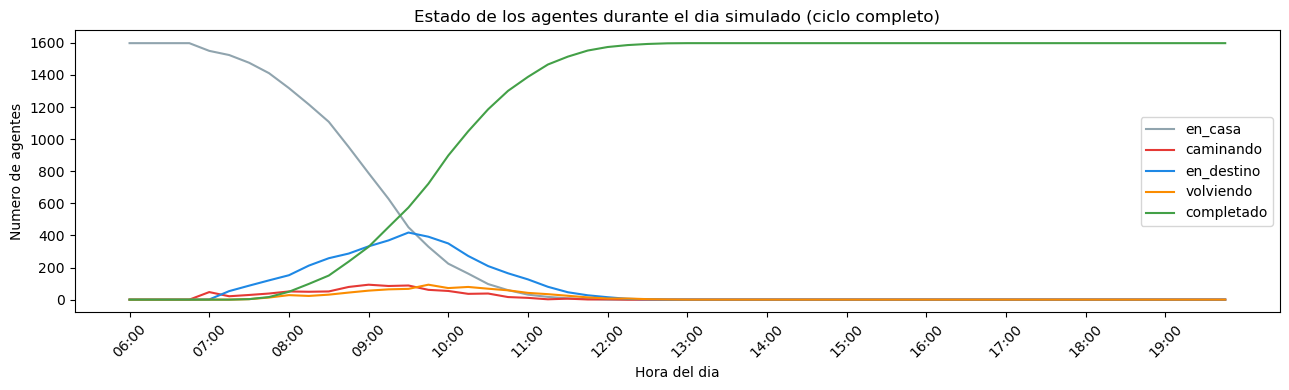

In [10]:
# Estado de agentes a lo largo del dia completo
summary = pd.concat(snapshots, ignore_index=True)

status_time = (
    summary
    .groupby(['time', 'status'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

colores = {
    'en_casa':    '#90A4AE',
    'caminando':  '#E53935',
    'en_destino': '#1E88E5',
    'volviendo':  '#FB8C00',
    'completado': '#43A047',
}

plt.figure(figsize=(13, 4))
for col, color in colores.items():
    if col in status_time.columns:
        plt.plot(status_time['time'], status_time[col], label=col, color=color)

tick_idx = list(range(0, len(status_time), 4))
plt.xticks([status_time['time'].iloc[i] for i in tick_idx], rotation=45)
plt.xlabel('Hora del dia')
plt.ylabel('Numero de agentes')
plt.title('Estado de los agentes durante el dia simulado (ciclo completo)')
plt.legend()
plt.tight_layout()
plt.show()

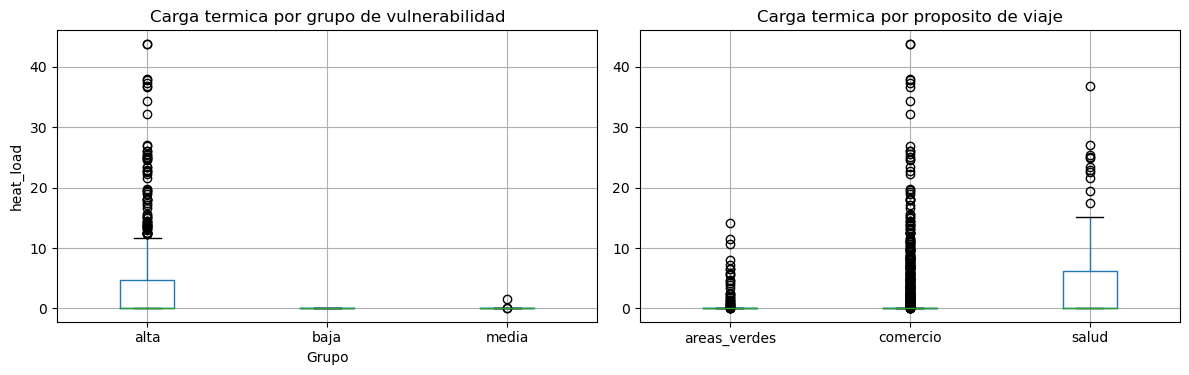


Resumen final por grupo de vulnerabilidad:
            count  mean  std  min  25%  50%  75%   max
vuln_group                                            
alta        641.0   3.7  6.9  0.0  0.0  0.1  4.7  43.9
baja        401.0   0.0  0.0  0.0  0.0  0.0  0.0   0.0
media       556.0   0.0  0.1  0.0  0.0  0.0  0.0   1.5


In [11]:
# Carga termica al final del dia
activos = final_agents[final_agents['status'] != 'en_casa'].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

activos.boxplot(column='heat_load', by='vuln_group', ax=axes[0])
axes[0].set_title('Carga termica por grupo de vulnerabilidad')
axes[0].set_xlabel('Grupo')
axes[0].set_ylabel('heat_load')

activos.boxplot(column='heat_load', by='purpose_group_model', ax=axes[1])
axes[1].set_title('Carga termica por proposito de viaje')
axes[1].set_xlabel('')

plt.suptitle('')
plt.tight_layout()
plt.show()

print('\nResumen final por grupo de vulnerabilidad:')
print(
    activos.groupby('vuln_group')['heat_load']
    .describe()
    .round(1)
)

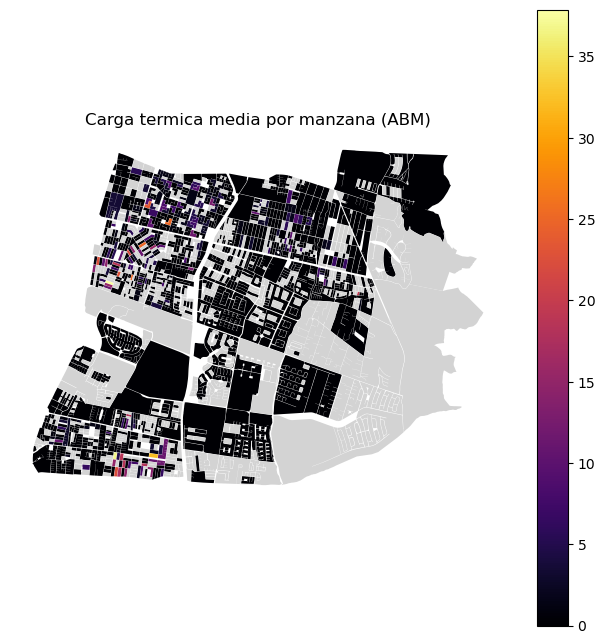

In [12]:
# Agregacion espacial por manzana
risk_map = (
    activos
    .groupby('MANZENT')
    .agg(
        n_agentes      = ('agent_id',  'count'),
        heat_mean      = ('heat_load', 'mean'),
        pct_risk_high  = ('risk_level', lambda x: (x == 'alto').mean()),
        pct_risk_medio = ('risk_level', lambda x: (x == 'medio').mean()),
    )
    .reset_index()
)

manz_plot = manz.merge(risk_map, on='MANZENT', how='left')

ax = manz_plot.plot(
    column='heat_mean',
    cmap='inferno',
    legend=True,
    figsize=(8, 8),
    missing_kwds={'color': 'lightgrey', 'label': 'Sin agentes activos'}
)
ax.set_title('Carga termica media por manzana (ABM)')
ax.set_axis_off()
plt.show()

## 6. Tracking espacial de agentes

Para cada snapshot se interpola la posición exacta del agente sobre su ruta usando `LineString.interpolate(distance_traveled)`.

- **en_casa** → coordenada de origen (punto representativo de la manzana)
- **caminando** → posición interpolada sobre la LineString de la ruta
- **en_destino** → coordenada del nodo destino

In [13]:
def enrich_snapshots(snapshots, walkers_geo):
    geo = walkers_geo[
        ['agent_id', 'x_rep', 'y_rep', 'x_dest', 'y_dest', 'route_geom', 'route_length_m']
    ].set_index('agent_id')

    enriched = []
    for snap in snapshots:
        s = snap.copy()

        s['x_pos'] = s['agent_id'].map(geo['x_rep'])
        s['y_pos'] = s['agent_id'].map(geo['y_rep'])

        # en destino
        mask_dest = s['status'] == 'en_destino'
        s.loc[mask_dest, 'x_pos'] = s.loc[mask_dest, 'agent_id'].map(geo['x_dest'])
        s.loc[mask_dest, 'y_pos'] = s.loc[mask_dest, 'agent_id'].map(geo['y_dest'])

        # caminando (outbound): interpolacion directa
        mask_walk = s['status'] == 'caminando'
        for idx in s[mask_walk].index:
            aid  = s.at[idx, 'agent_id']
            dist = s.at[idx, 'distance_traveled']
            geom = geo.at[aid, 'route_geom']
            if geom is not None and hasattr(geom, 'interpolate'):
                pt = geom.interpolate(min(dist, geom.length))
                s.at[idx, 'x_pos'] = pt.x
                s.at[idx, 'y_pos'] = pt.y

        # volviendo (return): interpolacion inversa
        mask_ret = s['status'] == 'volviendo'
        for idx in s[mask_ret].index:
            aid    = s.at[idx, 'agent_id']
            dist   = s.at[idx, 'distance_traveled']
            geom   = geo.at[aid, 'route_geom']
            rt_len = geo.at[aid, 'route_length_m']
            if geom is not None and hasattr(geom, 'interpolate'):
                pt = geom.interpolate(min(max(0, rt_len - dist), geom.length))
                s.at[idx, 'x_pos'] = pt.x
                s.at[idx, 'y_pos'] = pt.y

        enriched.append(s)

    return enriched


walkers_geo = walkers[
    ['agent_id', 'x_rep', 'y_rep', 'x_dest', 'y_dest', 'route_geom', 'route_length_m']
].copy()

print('Enriqueciendo snapshots con posiciones...')
enriched = enrich_snapshots(snapshots, walkers_geo)
print(f'Snapshots enriquecidos: {len(enriched)}')
enriched[0][['agent_id', 'status', 'x_pos', 'y_pos', 'distance_traveled']].head()

Enriqueciendo snapshots con posiciones...
Snapshots enriquecidos: 56


,agent_id,status,x_pos,y_pos,distance_traveled
0,5,en_casa,354095.616422,6.296589e+06,0.0
1,9,en_casa,353831.281093,6.296461e+06,0.0
2,16,en_casa,353977.039554,6.296382e+06,0.0
3,18,en_casa,354209.630397,6.296383e+06,0.0
4,22,en_casa,354401.459806,6.296332e+06,0.0


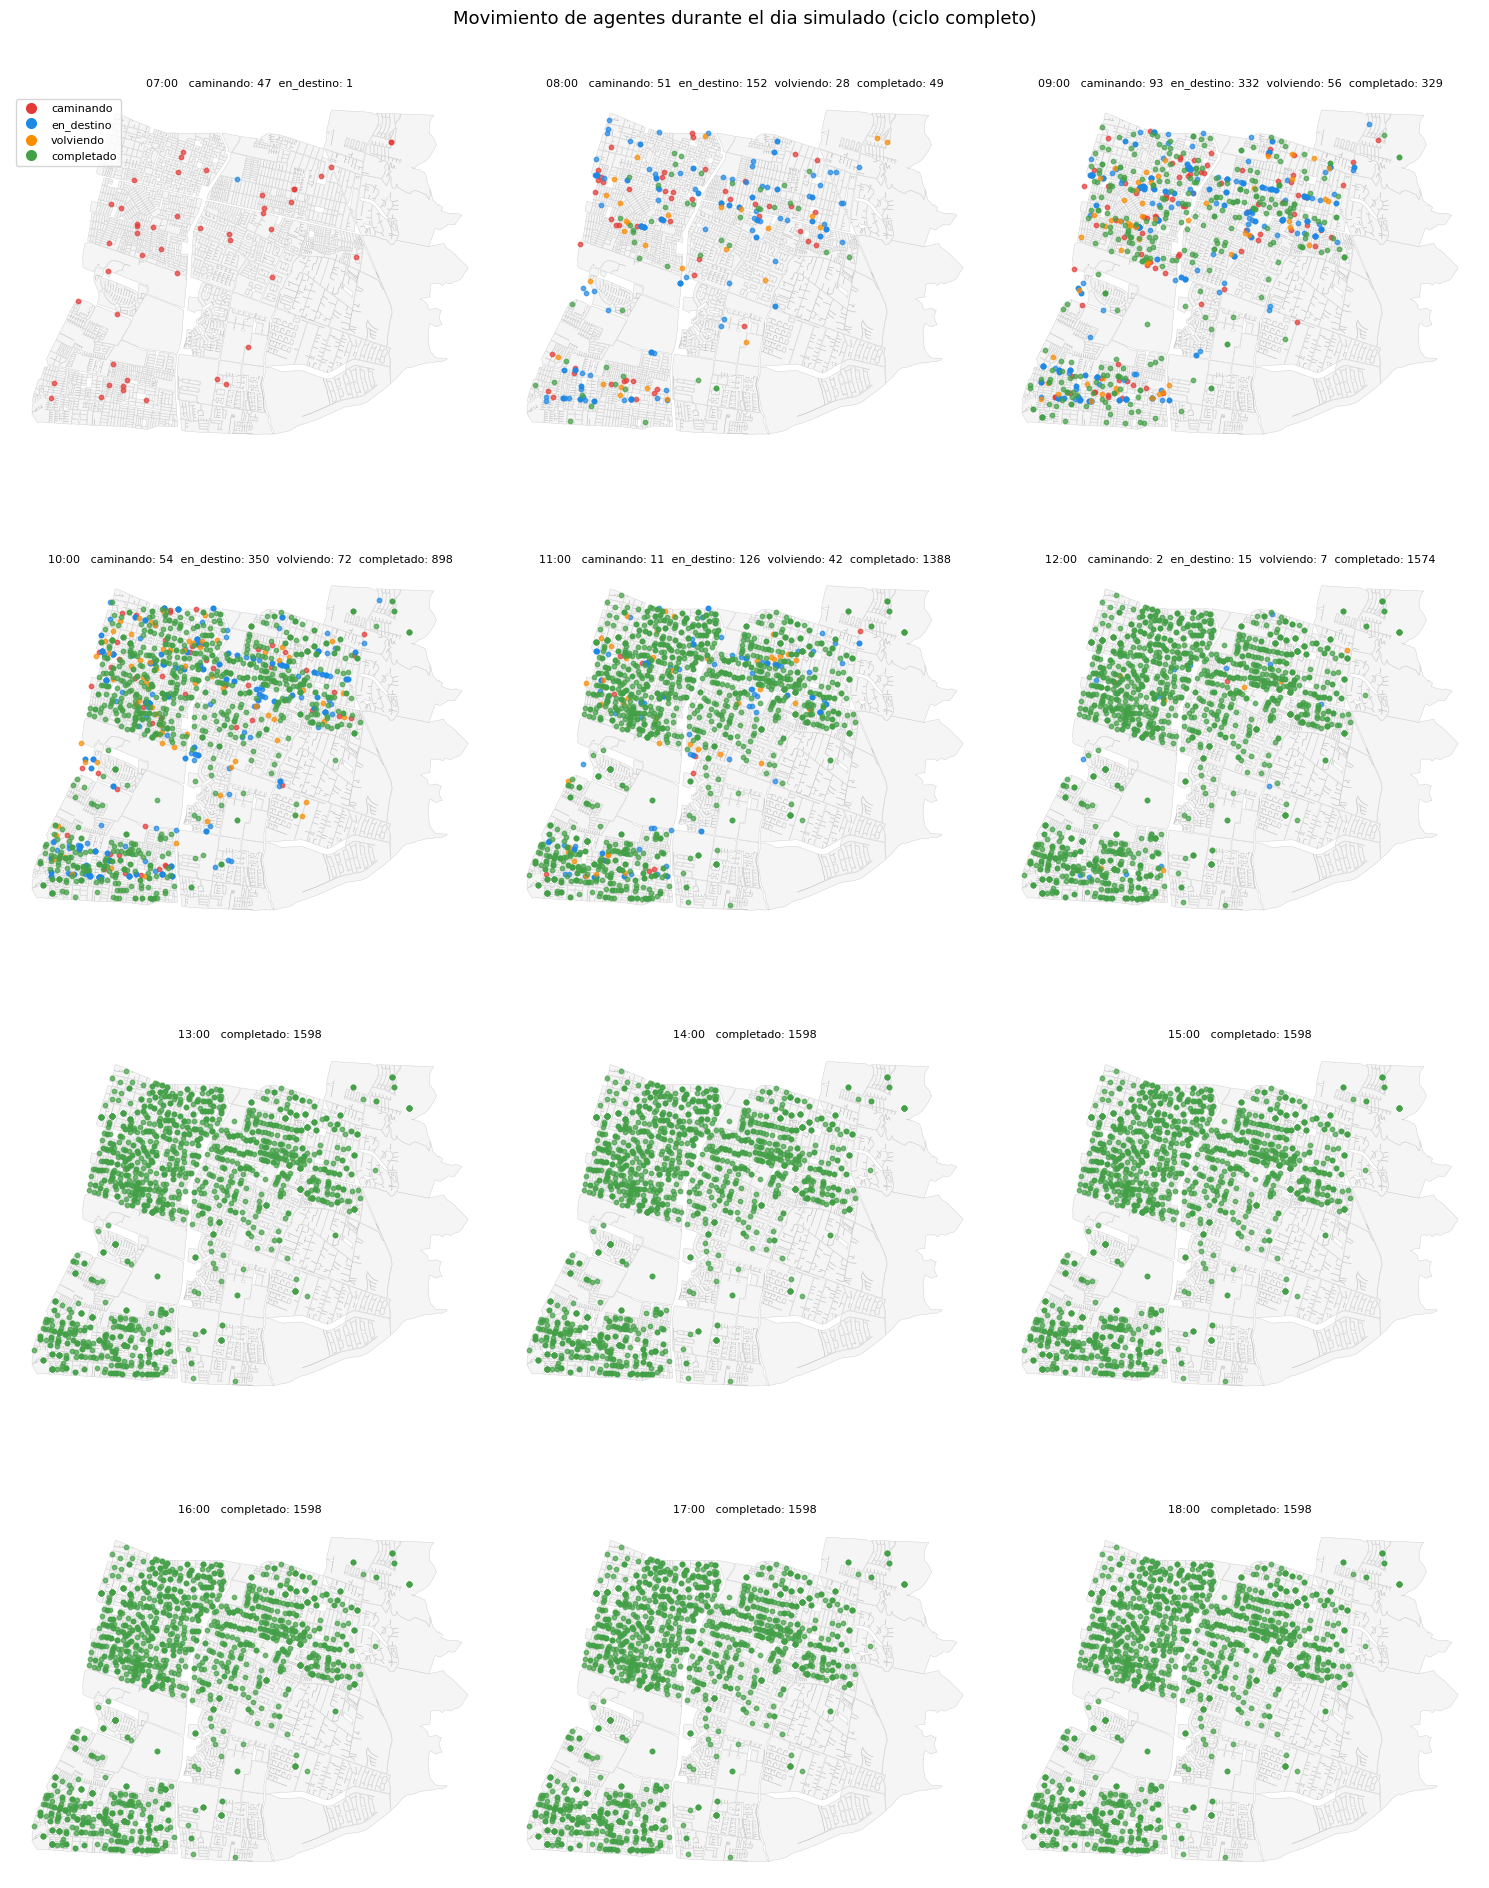

In [14]:
from matplotlib.lines import Line2D

status_colors = {
    'caminando':  '#E53935',
    'en_destino': '#1E88E5',
    'volviendo':  '#FB8C00',
    'completado': '#43A047',
}

snap_by_time = {s['time'].iloc[0]: s for s in enriched}
target_times = ['07:00', '08:00', '09:00', '10:00', '11:00', '12:00',
                '13:00', '14:00', '15:00', '16:00', '17:00', '18:00']
available = [t for t in target_times if t in snap_by_time]

cols = 3
n_rows = (len(available) + cols - 1) // cols

fig, axes = plt.subplots(n_rows, cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, t in enumerate(available):
    ax   = axes[i]
    snap = snap_by_time[t]

    manz.plot(ax=ax, color='whitesmoke', edgecolor='#cccccc', linewidth=0.3, zorder=1)

    for status, color in status_colors.items():
        sub = snap[snap['status'] == status]
        if not sub.empty:
            ax.scatter(sub['x_pos'], sub['y_pos'],
                       c=color, s=10, alpha=0.7, zorder=3)

    counts = snap['status'].value_counts()
    label = '  '.join(
        f'{s}: {counts.get(s, 0)}'
        for s in ['caminando', 'en_destino', 'volviendo', 'completado']
        if counts.get(s, 0) > 0
    )
    ax.set_title(f'{t}   {label}', fontsize=8)
    ax.set_axis_off()

legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=c, markersize=9, label=s)
    for s, c in status_colors.items()
]
axes[0].legend(handles=legend_elements, loc='upper left', fontsize=8)

for j in range(len(available), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Movimiento de agentes durante el dia simulado (ciclo completo)', fontsize=13)
plt.tight_layout()
plt.show()

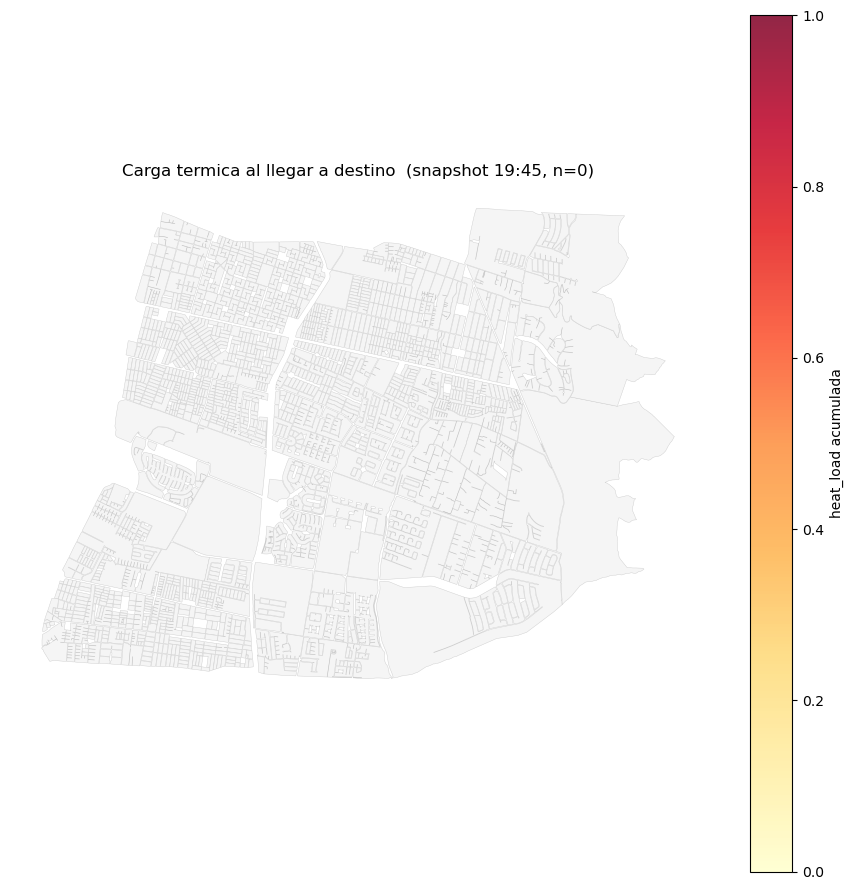

In [15]:
# Carga termica al momento de llegar al destino (ultimo snapshot disponible)
last_snap  = enriched[-1]
en_destino = last_snap[last_snap['status'] == 'en_destino'].copy()

fig, ax = plt.subplots(figsize=(9, 9))
manz.plot(ax=ax, color='whitesmoke', edgecolor='#cccccc', linewidth=0.3, zorder=1)

sc = ax.scatter(
    en_destino['x_pos'], en_destino['y_pos'],
    c=en_destino['heat_load'],
    cmap='YlOrRd', s=14, alpha=0.85, zorder=3
)
plt.colorbar(sc, ax=ax, label='heat_load acumulada')
ax.set_title(
    f'Carga termica al llegar a destino  '
    f'(snapshot {last_snap["time"].iloc[0]}, n={len(en_destino)})'
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 7. Comparación exposición estática vs dinámica

La **exposición estática** usa el NDVI residencial como proxy de exposición al calor:

```
static_exposure = 1 − ndvi_norm
```

La **exposición dinámica** proviene de la carga térmica simulada (normalizada a [0, 1]):

```
dynamic_exposure_norm = minmax_norm(heat_load)
```

La diferencia:

```
delta_exp = dynamic_exposure_norm − static_exposure_norm
```

Valores negativos indican que el enfoque residencial **sobreestima** la exposición real respecto al modelo de trayectoria.

In [16]:
# Construir tabla de comparacion a nivel de agente
# final_agents tiene heat_load y MANZENT (heredado de walkers via build_agents)
walkers_static = walkers[['agent_id', 'MANZENT', 'ndvi_norm']].copy()

exp_df = (
    final_agents[final_agents['status'] != 'en_casa']
    [['agent_id', 'heat_load', 'vuln_group', 'purpose_group_model']]
    .merge(walkers_static, on='agent_id')
)

# Exposicion estatica: residencial
exp_df['static_exposure'] = 1 - exp_df['ndvi_norm']

# Exposicion dinamica: heat_load normalizada a [0, 1]
hl_min = exp_df['heat_load'].min()
hl_max = exp_df['heat_load'].max()
exp_df['dynamic_exposure_norm'] = (exp_df['heat_load'] - hl_min) / (hl_max - hl_min + 1e-9)

# Diferencia
exp_df['delta_exp'] = exp_df['dynamic_exposure_norm'] - exp_df['static_exposure']

print(f'Agentes con comparacion: {len(exp_df)}')
print(f'\ndelta_exp  (dinamica - estatica):')
print(exp_df['delta_exp'].describe().round(3))
print(f'\n  < 0  (estatica sobreestima): {(exp_df["delta_exp"] < 0).sum()}  '
      f'({(exp_df["delta_exp"] < 0).mean():.1%})')
print(f'  > 0  (dinamica mayor):        {(exp_df["delta_exp"] > 0).sum()}  '
      f'({(exp_df["delta_exp"] > 0).mean():.1%})')

Agentes con comparacion: 1598

delta_exp  (dinamica - estatica):
count    1598.000
mean       -0.696
std         0.173
min        -1.000
25%        -0.814
50%        -0.726
75%        -0.604
max         0.291
Name: delta_exp, dtype: float64

  < 0  (estatica sobreestima): 1589  (99.4%)
  > 0  (dinamica mayor):        7  (0.4%)


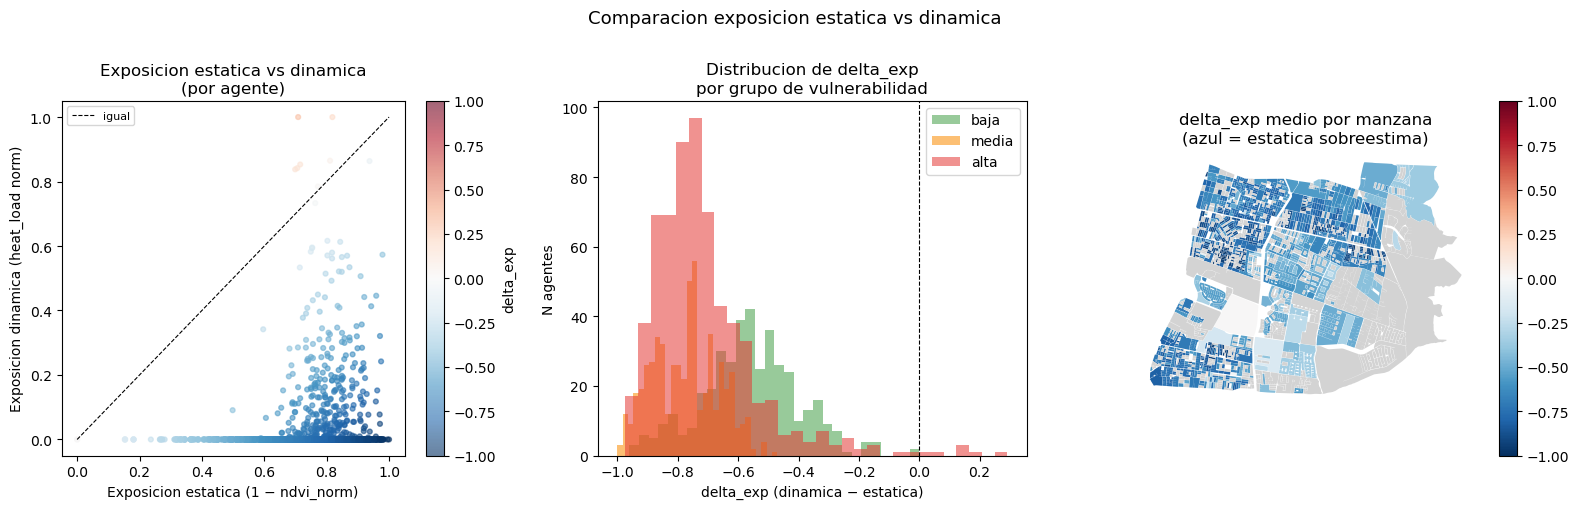

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- 1. Scatter: estatica vs dinamica ---
ax = axes[0]
sc = ax.scatter(
    exp_df['static_exposure'],
    exp_df['dynamic_exposure_norm'],
    c=exp_df['delta_exp'], cmap='RdBu_r', vmin=-1, vmax=1,
    s=12, alpha=0.6
)
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='igual')
plt.colorbar(sc, ax=ax, label='delta_exp')
ax.set_xlabel('Exposicion estatica (1 − ndvi_norm)')
ax.set_ylabel('Exposicion dinamica (heat_load norm)')
ax.set_title('Exposicion estatica vs dinamica\n(por agente)')
ax.legend(fontsize=8)

# --- 2. Histograma de delta_exp por grupo de vulnerabilidad ---
ax = axes[1]
for vg, color in [('baja', '#43A047'), ('media', '#FB8C00'), ('alta', '#E53935')]:
    sub = exp_df[exp_df['vuln_group'] == vg]['delta_exp']
    ax.hist(sub, bins=30, alpha=0.55, label=vg, color=color)
ax.axvline(0, color='black', lw=0.8, linestyle='--')
ax.set_xlabel('delta_exp (dinamica − estatica)')
ax.set_ylabel('N agentes')
ax.set_title('Distribucion de delta_exp\npor grupo de vulnerabilidad')
ax.legend()

# --- 3. delta_exp medio por manzana (mapa) ---
ax = axes[2]
delta_manz = (
    exp_df.groupby('MANZENT')['delta_exp']
    .mean()
    .reset_index()
    .rename(columns={'delta_exp': 'delta_mean'})
)
manz_delta = manz.merge(delta_manz, on='MANZENT', how='left')
manz_delta.plot(
    column='delta_mean', cmap='RdBu_r', vmin=-1, vmax=1,
    legend=True, ax=ax,
    missing_kwds={'color': 'lightgrey', 'label': 'Sin walkers'}
)
ax.set_title('delta_exp medio por manzana\n(azul = estatica sobreestima)')
ax.set_axis_off()

plt.suptitle('Comparacion exposicion estatica vs dinamica', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 8. Exportar resultados

Guarda los outputs principales para no tener que re-ejecutar el pipeline completo.

In [18]:
OUT = Path('../outputs/abm')
OUT.mkdir(parents=True, exist_ok=True)

# Estado final de todos los agentes
cols_export = [
    'agent_id', 'MANZENT', 'vuln_group', 'purpose_group_model',
    'route_length_m', 'ndvi_route', 'ndvi_cooling', 'wbgt_umbral',
    'departure_step', 'dwell_steps', 'arrival_step',
    'status', 'heat_load', 'risk_level'
]
final_agents[cols_export].to_parquet(OUT / 'final_agents.parquet', index=False)

# Comparacion estatica vs dinamica por agente
exp_df.to_parquet(OUT / 'exposure_comparison.parquet', index=False)

# Snapshots concatenados (estado de todos los agentes cada 15 min)
snap_all = pd.concat(snapshots, ignore_index=True)
snap_all.to_parquet(OUT / 'snapshots.parquet', index=False)

print('Exportado a', OUT)
print(f'  final_agents.parquet        {len(final_agents[cols_export])} filas')
print(f'  exposure_comparison.parquet {len(exp_df)} filas')
print(f'  snapshots.parquet           {len(snap_all)} filas  '
      f'({len(snapshots)} snapshots × {len(final_agents)} agentes)')

Exportado a ..\outputs\abm
  final_agents.parquet        1598 filas
  exposure_comparison.parquet 1598 filas
  snapshots.parquet           89488 filas  (56 snapshots × 1598 agentes)


## 9. Análisis de escenarios

**Escenario: infraestructura verde**

Se simula un aumento de NDVI en las manzanas con menor vegetación (cuartil inferior de `ndvi_norm`), representando una intervención de arborización o pavimento permeable. El resto del modelo es idéntico al baseline.

El parámetro `NDVI_BOOST` controla el incremento absoluto de `ndvi_norm` en las manzanas intervenidas.

In [19]:
NDVI_BOOST = 0.20   # incremento absoluto de ndvi_route en manzanas intervenidas

# Manzanas del cuartil inferior de NDVI
q25 = manz['ndvi_norm'].quantile(0.25)
manz_interv = set(manz.loc[manz['ndvi_norm'] <= q25, 'MANZENT'])
print(f'Manzanas intervenidas (ndvi_norm ≤ {q25:.3f}): {len(manz_interv)}')

# Walkers con NDVI modificado
walkers_scen = walkers.copy()
mask_interv  = walkers_scen['MANZENT'].isin(manz_interv)
walkers_scen.loc[mask_interv, 'ndvi_route'] = (
    walkers_scen.loc[mask_interv, 'ndvi_route'] + NDVI_BOOST
).clip(upper=1.0)
print(f'Walkers afectados: {mask_interv.sum()} / {len(walkers_scen)}')

# Mismo config y seed → mismas horas de salida, solo cambia ndvi_cooling
agents_scen = build_agents(
    walkers_scen, ndvi_min=ndvi_min, ndvi_max=ndvi_max, config=cfg, seed=SEED
)
final_scen, _ = run(
    agents_scen, wbgt_profile=wbgt_profile, config=cfg, snapshot_every=SNAPSHOT_EVERY
)

print('\nEstado final escenario verde:')
print(final_scen['status'].value_counts())

Manzanas intervenidas (ndvi_norm ≤ 0.146): 408
Walkers afectados: 344 / 1598

Estado final escenario verde:
status
completado    1598
Name: count, dtype: int64


In [20]:
# Comparar heat_load baseline vs escenario
activos_base = final_agents[final_agents['status'] != 'en_casa'][['agent_id', 'heat_load', 'vuln_group', 'MANZENT']].copy()
activos_scen = final_scen[final_scen['status'] != 'en_casa'][['agent_id', 'heat_load']].copy()

comp = activos_base.merge(
    activos_scen.rename(columns={'heat_load': 'heat_load_scen'}),
    on='agent_id'
)
comp['reduccion'] = comp['heat_load'] - comp['heat_load_scen']
comp['reduccion_pct'] = comp['reduccion'] / comp['heat_load'] * 100

print('Reduccion de heat_load (baseline - escenario verde):')
print(comp['reduccion'].describe().round(1))
print(f'\nReduccion media: {comp["reduccion"].mean():.1f}  ({comp["reduccion_pct"].mean():.1f}%)')
print(f'\nPor grupo de vulnerabilidad:')
print(
    comp.groupby('vuln_group')[['reduccion', 'reduccion_pct']]
    .mean().round(2)
)

Reduccion de heat_load (baseline - escenario verde):
count    1598.0
mean        0.4
std         2.1
min         0.0
25%         0.0
50%         0.0
75%         0.0
max        31.3
Name: reduccion, dtype: float64

Reduccion media: 0.4  (23.3%)

Por grupo de vulnerabilidad:
            reduccion  reduccion_pct
vuln_group                          
alta             0.88          22.89
baja             0.00            NaN
media            0.00          66.67


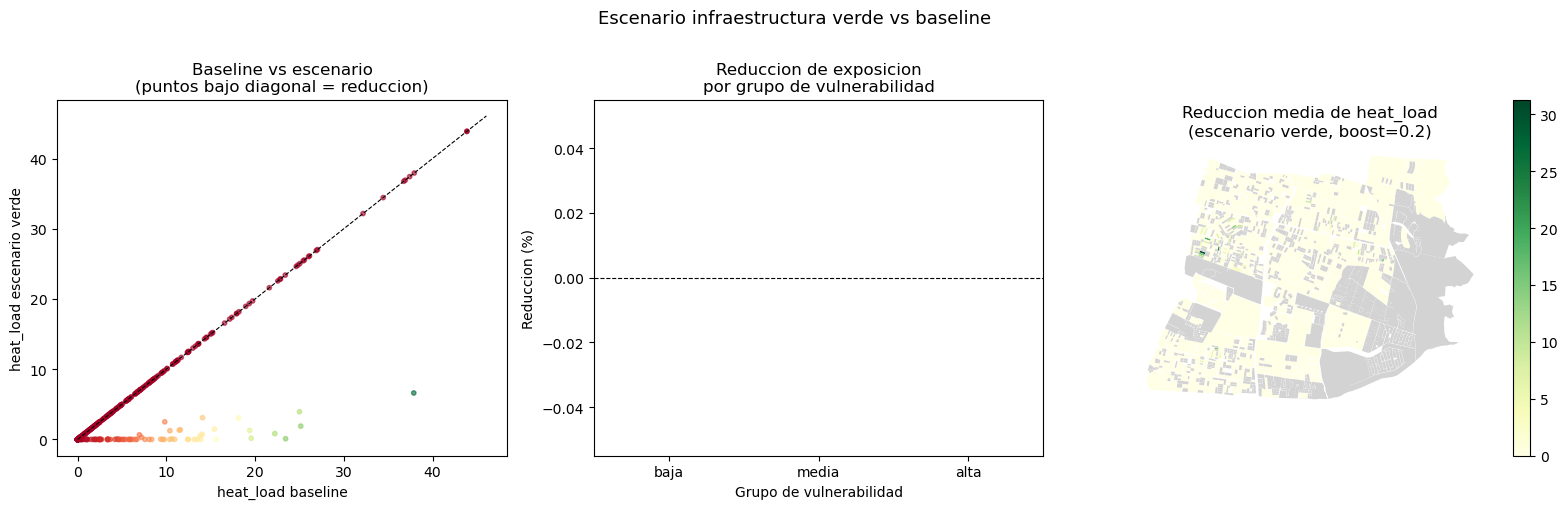

Guardado: outputs/abm/scenario_verde_comparison.parquet


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- 1. Scatter baseline vs escenario por agente ---
ax = axes[0]
ax.scatter(comp['heat_load'], comp['heat_load_scen'],
           c=comp['reduccion'], cmap='RdYlGn', s=10, alpha=0.6)
lim = max(comp['heat_load'].max(), comp['heat_load_scen'].max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', lw=0.8)
ax.set_xlabel('heat_load baseline')
ax.set_ylabel('heat_load escenario verde')
ax.set_title('Baseline vs escenario\n(puntos bajo diagonal = reduccion)')

# --- 2. Boxplot de reduccion por grupo de vulnerabilidad ---
ax = axes[1]
grupos = ['baja', 'media', 'alta']
data   = [comp.loc[comp['vuln_group'] == g, 'reduccion_pct'].values for g in grupos]
bp = ax.boxplot(data, labels=grupos, patch_artist=True)
colors = ['#43A047', '#FB8C00', '#E53935']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_xlabel('Grupo de vulnerabilidad')
ax.set_ylabel('Reduccion (%)')
ax.set_title('Reduccion de exposicion\npor grupo de vulnerabilidad')

# --- 3. Mapa de reduccion media por manzana ---
ax = axes[2]
red_manz = (
    comp.groupby('MANZENT')['reduccion']
    .mean().reset_index()
    .rename(columns={'reduccion': 'red_mean'})
)
manz_red = manz.merge(red_manz, on='MANZENT', how='left')
manz_red.plot(
    column='red_mean', cmap='YlGn', legend=True, ax=ax,
    missing_kwds={'color': 'lightgrey', 'label': 'Sin walkers'}
)
ax.set_title(f'Reduccion media de heat_load\n(escenario verde, boost={NDVI_BOOST})')
ax.set_axis_off()

plt.suptitle('Escenario infraestructura verde vs baseline', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Guardar comparacion escenario
comp.to_parquet(OUT / 'scenario_verde_comparison.parquet', index=False)
print('Guardado: outputs/abm/scenario_verde_comparison.parquet')

## 10. Validación — Respuesta del modelo a tres perfiles meteorológicos

Se corren tres escenarios con condiciones meteorológicas contrastadas para verificar que el modelo responde correctamente a variaciones de WBGT.

| Escenario | T_max | HR_min | Rs_max | Descripción |
|---|---|---|---|---|
| Día moderado (límite inferior) | 28°C | 35% | 850 W/m² | Límite inferior — verano suave |
| Día típico de verano (baseline) | 32°C | 28% | 950 W/m² | Representativo de enero en Santiago |
| Ola de calor severa | 36°C | 20% | 1000 W/m² | Condición extrema — estrés del modelo |

**Criterio de coherencia**: el heat_load medio debe ser estrictamente creciente entre escenarios, y el porcentaje de agentes en riesgo alto debe diferenciar claramente entre grupos de vulnerabilidad.  
**threshold_high = 60 °C·min** (ajustado desde 90 para mejor distribución entre categorías).

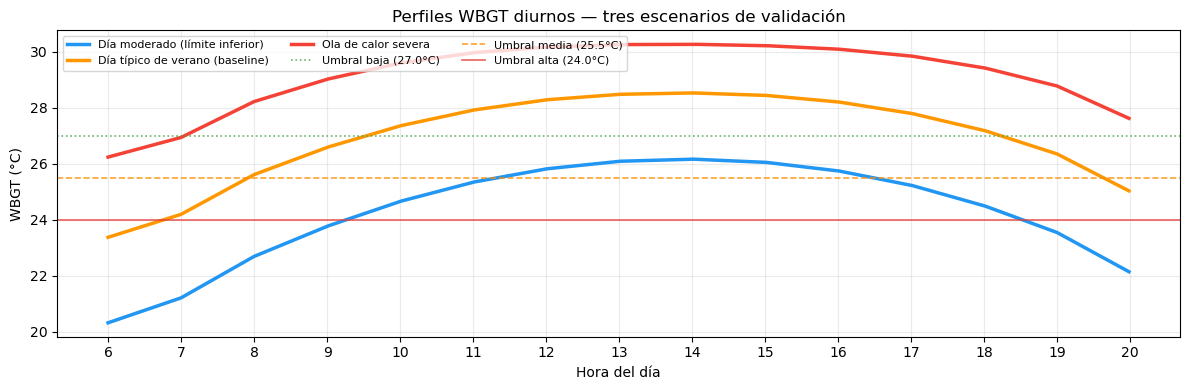

WBGT peak por escenario:
  Día moderado (límite inferior)            max=26.16°C  (14:00)
  Día típico de verano (baseline)           max=28.53°C  (14:00)
  Ola de calor severa                       max=30.26°C  (14:00)


In [22]:
# --- Definir tres perfiles ---
perfiles = {
    'Día moderado\n(límite inferior)':       dict(T_max=28.0, HR_min=35.0, Rs_max=850.0),
    'Día típico de verano\n(baseline)':      dict(T_max=32.0, HR_min=28.0, Rs_max=950.0),
    'Ola de calor severa':                   dict(T_max=36.0, HR_min=20.0, Rs_max=1000.0),
}
COLORES_PERF = ['#2196F3', '#FF9800', '#F44336']

cfg_val = SimConfig()   # threshold_high=60, threshold_med=30
horas_eje = np.arange(cfg_val.n_steps) / 60 + 6

# --- Visualizar perfiles WBGT y umbrales ---
fig, ax = plt.subplots(figsize=(12, 4))

for (nombre, params), color in zip(perfiles.items(), COLORES_PERF):
    perfil = make_wbgt_profile(**params, config=cfg_val)
    ax.plot(horas_eje, perfil, label=nombre.replace('\n', ' '), color=color, lw=2.5)

umbrales = {
    f'Umbral baja ({cfg_val.wbgt_umbral_base}°C)':
        (cfg_val.wbgt_umbral_base - cfg_val.vuln_delta.get('baja', 0),  '#43A047', ':'),
    f'Umbral media ({cfg_val.wbgt_umbral_base - cfg_val.vuln_delta.get("media", 1)}°C)':
        (cfg_val.wbgt_umbral_base - cfg_val.vuln_delta.get('media', 1), '#FB8C00', '--'),
    f'Umbral alta ({cfg_val.wbgt_umbral_base - cfg_val.vuln_delta.get("alta", 2)}°C)':
        (cfg_val.wbgt_umbral_base - cfg_val.vuln_delta.get('alta', 2),  '#E53935', '-'),
}
for label, (val, color, ls) in umbrales.items():
    ax.axhline(val, color=color, lw=1.2, ls=ls, alpha=0.8, label=label)

ax.set_xlabel('Hora del día')
ax.set_ylabel('WBGT (°C)')
ax.set_title('Perfiles WBGT diurnos — tres escenarios de validación')
ax.set_xticks(range(6, 21))
ax.legend(fontsize=8, ncol=3, loc='upper left')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print('WBGT peak por escenario:')
for nombre, params in perfiles.items():
    p = make_wbgt_profile(**params, config=cfg_val)
    print(f'  {nombre.replace(chr(10), " "):40s}  '
          f'max={p.max():.2f}°C  ({step_to_time(int(p.argmax()), cfg_val)})')

In [23]:
# --- Correr simulacion para cada perfil ---
resultados_val = {}

for nombre, params in perfiles.items():
    perfil  = make_wbgt_profile(**params, config=cfg_val)
    agentes = build_agents(
        walkers, ndvi_min=ndvi_min, ndvi_max=ndvi_max, config=cfg_val, seed=SEED
    )
    final, _ = run(agentes, wbgt_profile=perfil, config=cfg_val, snapshot_every=60)
    activos_v = final[final['status'] != 'en_casa'].copy()
    activos_v['escenario'] = nombre.replace('\n', ' ')
    resultados_val[nombre] = {'final': final, 'activos': activos_v}

# --- Tabla resumen de coherencia ---
print(f'{"Escenario":<32} {"heat_load medio":>16} {"% riesgo medio":>15} {"% riesgo alto":>14}')
print('-' * 80)
for nombre, res in resultados_val.items():
    a = res['activos']
    hl_med  = a['heat_load'].mean()
    pct_med = (a['risk_level'] == 'medio').mean() * 100
    pct_alt = (a['risk_level'] == 'alto').mean()  * 100
    print(f'{nombre.replace(chr(10)," "):<32} {hl_med:>16.1f} {pct_med:>14.1f}% {pct_alt:>13.1f}%')

print('\n✓ Coherencia: heat_load debe aumentar de fila 1 a fila 3.')

Escenario                         heat_load medio  % riesgo medio  % riesgo alto
--------------------------------------------------------------------------------
Día moderado (límite inferior)                1.5            0.6%           0.0%
Día típico de verano (baseline)              22.4           17.7%          10.6%
Ola de calor severa                          57.4           28.7%          36.7%

✓ Coherencia: heat_load debe aumentar de fila 1 a fila 3.


C:\Users\mbell\AppData\Local\Temp\ipykernel_22864\2042530571.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['risk_level'] == 'alto').mean() * 100)


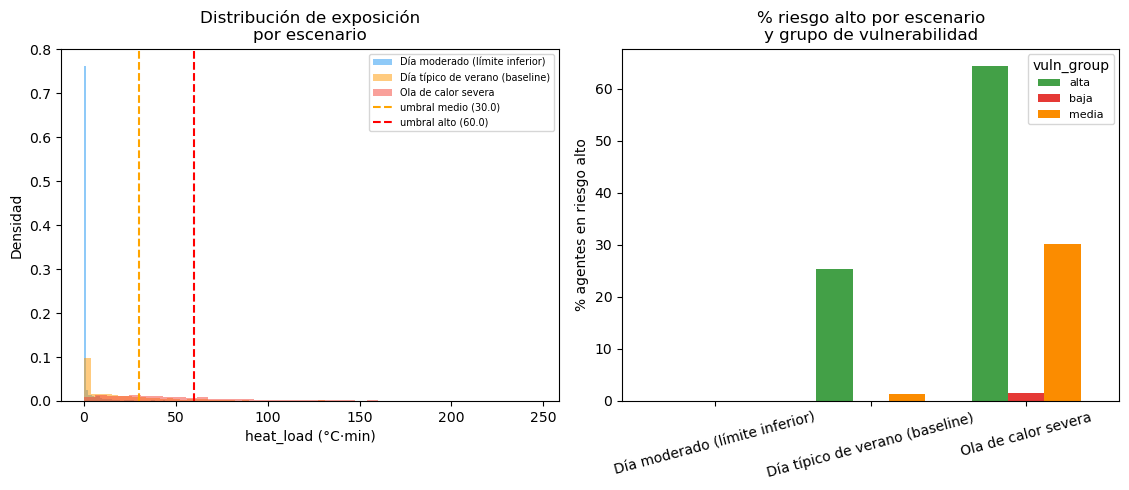

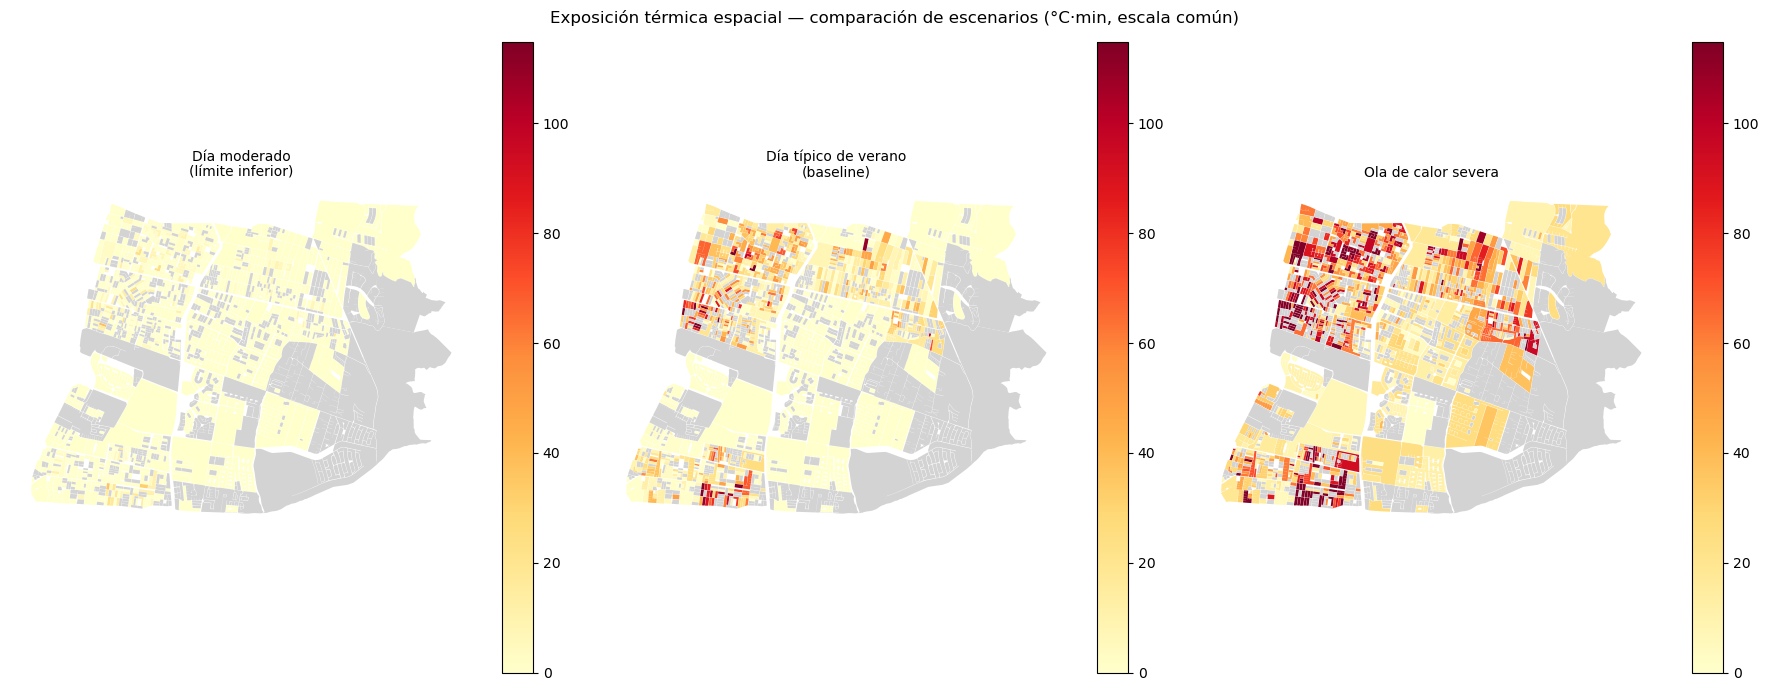

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- 1. Histograma de heat_load por escenario ---
ax = axes[0]
for (nombre, res), color in zip(resultados_val.items(), COLORES_PERF):
    a = res['activos']
    ax.hist(a['heat_load'], bins=40, alpha=0.5, density=True,
            label=nombre.replace('\n', ' '), color=color)
ax.axvline(cfg_val.threshold_med,  color='orange', lw=1.5, ls='--',
           label=f'umbral medio ({cfg_val.threshold_med})')
ax.axvline(cfg_val.threshold_high, color='red',    lw=1.5, ls='--',
           label=f'umbral alto ({cfg_val.threshold_high})')
ax.set_xlabel('heat_load (°C·min)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de exposición\npor escenario')
ax.legend(fontsize=7)

# --- 2. % en riesgo alto por escenario y grupo de vulnerabilidad ---
ax = axes[1]
todos_val = pd.concat([r['activos'] for r in resultados_val.values()], ignore_index=True)
pivot_alto = (
    todos_val
    .groupby(['escenario', 'vuln_group'])
    .apply(lambda x: (x['risk_level'] == 'alto').mean() * 100)
    .unstack(fill_value=0)
)
pivot_alto.plot(kind='bar', ax=ax,
                color=['#43A047', '#E53935', '#FB8C00'],
                rot=15, width=0.7)
ax.set_xlabel('')
ax.set_ylabel('% agentes en riesgo alto')
ax.set_title('% riesgo alto por escenario\ny grupo de vulnerabilidad')
ax.legend(title='vuln_group', fontsize=8)

# --- 3. Mapas de heat_mean por manzana (tres columnas en un solo subplot) ---
ax = axes[2]
ax.set_visible(False)  # placeholder — usar figura separada para los tres mapas

plt.tight_layout()
plt.show()

# Figura separada: tres mapas lado a lado
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 7))
vmax_global = max(
    r['activos']['heat_load'].mean() for r in resultados_val.values()
) * 2.0

for ax2, (nombre, res), color in zip(axes2, resultados_val.items(), COLORES_PERF):
    heat_manz = (
        res['activos']
        .groupby('MANZENT')['heat_load']
        .mean().reset_index()
        .rename(columns={'heat_load': 'heat_mean'})
    )
    manz_v = manz.merge(heat_manz, on='MANZENT', how='left')
    manz_v.plot(
        column='heat_mean', cmap='YlOrRd', legend=True, ax=ax2,
        vmin=0, vmax=vmax_global,
        missing_kwds={'color': 'lightgrey', 'label': 'Sin walkers'}
    )
    ax2.set_title(nombre.replace('\n', '\n'), fontsize=10)
    ax2.set_axis_off()

fig2.suptitle('Exposición térmica espacial — comparación de escenarios (°C·min, escala común)',
              fontsize=12)
plt.tight_layout()
plt.show()